<a href="https://colab.research.google.com/github/empatiharshit28-cyber/Data_Analytics/blob/main/DA_assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv('/content/PGDAI_Probability_Distributions_Dataset - PGDAI_Probability_Distributions_Dataset (1).csv')

In [ ]:
import numpy as np
import scipy.stats as stats


mean_processing = df['Processing_Time'].mean()
std_processing = df['Processing_Time'].std()

print(f"Sample Mean (μ) of Processing_Time: {mean_processing:.4f}")
print(f"Sample Standard Deviation (σ) of Processing_Time: {std_processing:.4f}")

Sample Mean (μ) of Processing_Time: 3.9998
Sample Standard Deviation (σ) of Processing_Time: 1.4077


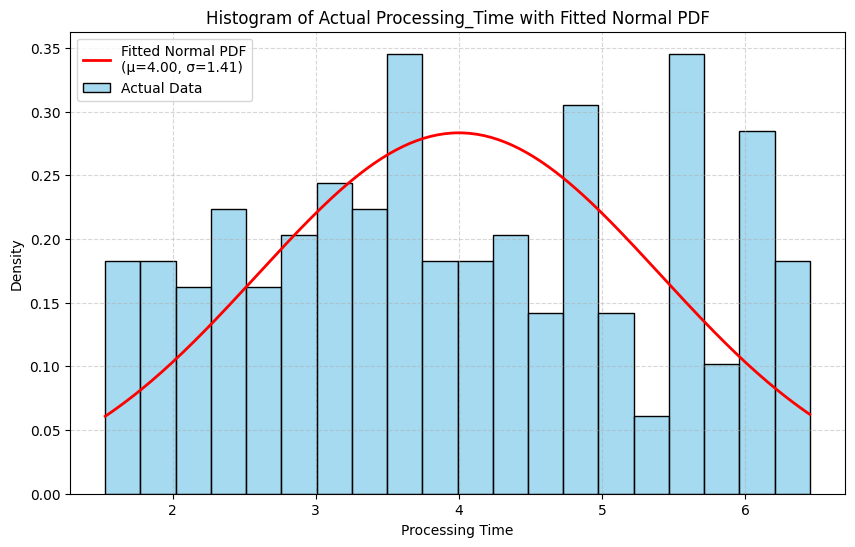

In [ ]:




import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual distribution with fitted Normal PDF curve
plt.figure(figsize=(10, 6))
sns.histplot(df['Processing_Time'], kde=False, stat="density", bins=20, color='skyblue', label='Actual Data')

# Generate points for the theoretical normal PDF curve
x = np.linspace(df['Processing_Time'].min(), df['Processing_Time'].max(), 200)
pdf = stats.norm.pdf(x, mean_processing, std_processing)
plt.plot(x, pdf, 'r-', lw=2, label=f'Fitted Normal PDF\n(μ={mean_processing:.2f}, σ={std_processing:.2f})')

plt.title('Histogram of Actual Processing_Time with Fitted Normal PDF')
plt.xlabel('Processing Time')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

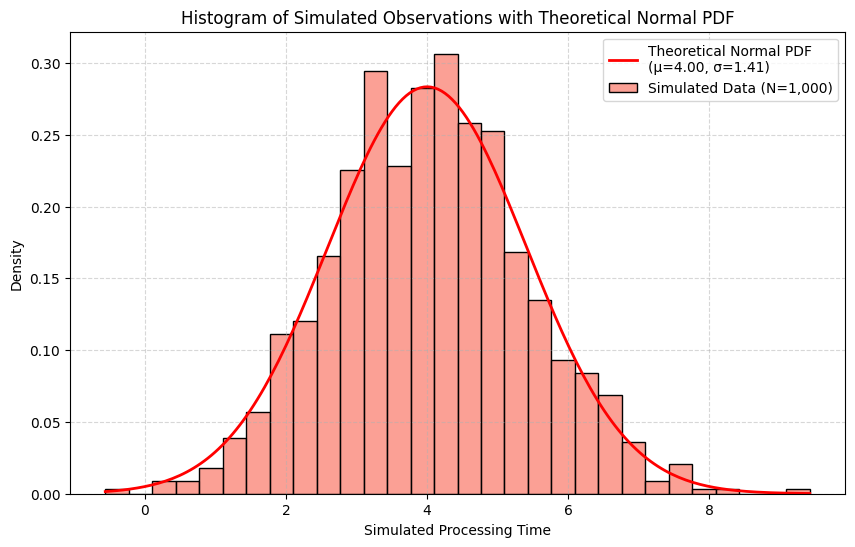

In [ ]:
# Generate 1,000 simulated observations using the estimated parameters
np.random.seed(42)  # For reproducibility
simulated_data = np.random.normal(loc=mean_processing, scale=std_processing, size=1000)

# Plot simulated data histogram with the same theoretical PDF
plt.figure(figsize=(10, 6))
sns.histplot(simulated_data, kde=False, stat="density", bins=30, color='salmon', label='Simulated Data (N=1,000)')

# Generate theoretical PDF curve
x_sim = np.linspace(simulated_data.min(), simulated_data.max(), 200)
pdf_sim = stats.norm.pdf(x_sim, mean_processing, std_processing)
plt.plot(x_sim, pdf_sim, 'r-', lw=2, label=f'Theoretical Normal PDF\n(μ={mean_processing:.2f}, σ={std_processing:.2f})')

plt.title('Histogram of Simulated Observations with Theoretical Normal PDF')
plt.xlabel('Simulated Processing Time')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# 14. Calculate the average response time
average_response_time = df['Response_Time'].mean()

# 15. Estimate the exponential rate parameter (lambda)
lambda_rate = 1.0 / average_response_time

print(f"Average Response Time (Mean): {average_response_time:.4f}")
print(f"Estimated Exponential Rate Parameter (λ): {lambda_rate:.4f}")

Average Response Time (Mean): 2.2674
Estimated Exponential Rate Parameter (λ): 0.4410


In [ ]:
import scipy.stats as stats

# 5. Calculate lambda from the sample mean of Support_Tickets
lambda_tickets = df['Support_Tickets'].mean()

# 6. Calculate the probability of exactly 3 support tickets in a day, P(X = 3)
prob_exactly_3 = stats.poisson.pmf(3, lambda_tickets)

# 7. Calculate the probability of fewer than 3 tickets in a day, P(X < 3) => P(X <= 2)
prob_fewer_than_3 = stats.poisson.cdf(2, lambda_tickets)

print(f"Estimated Lambda (mean support tickets per day): {lambda_tickets:.4f}")
print(f"P(X = 3) - Probability of exactly 3 tickets: {prob_exactly_3:.4f}")
print(f"P(X < 3) - Probability of fewer than 3 tickets: {prob_fewer_than_3:.4f}")

Estimated Lambda (mean support tickets per day): 2.1350
P(X = 3) - Probability of exactly 3 tickets: 0.1918
P(X < 3) - Probability of fewer than 3 tickets: 0.6402


In [ ]:
# 1. Estimate p (probability of incorrect prediction) from the dataset
p_incorrect = df['Defective_Model'].mean()
n_trials = 10

# 2. Probability of exactly 2 incorrect predictions, P(X = 2)
prob_exactly_2 = stats.binom.pmf(2, n_trials, p_incorrect)

# 3. Probability of at most 2 incorrect predictions, P(X <= 2)
prob_at_most_2 = stats.binom.cdf(2, n_trials, p_incorrect)

# 4. Probability of at least 3 incorrect predictions, P(X >= 3)
prob_at_least_3 = 1 - prob_at_most_2

print(f"Estimated Probability (p): {p_incorrect:.4f}")
print(f"P(X = 2) - Probability of exactly 2 incorrect predictions: {prob_exactly_2:.4f}")
print(f"P(X <= 2) - Probability of at most 2 incorrect predictions: {prob_at_most_2:.4f}")
print(f"P(X >= 3) - Probability of at least 3 incorrect predictions: {prob_at_least_3:.4f}")

Estimated Probability (p): 0.0750
P(X = 2) - Probability of exactly 2 incorrect predictions: 0.1357
P(X <= 2) - Probability of at most 2 incorrect predictions: 0.9661
P(X >= 3) - Probability of at least 3 incorrect predictions: 0.0339


In [ ]:
# 11. Find the lower bound a (observed minimum) and upper bound b (observed maximum)
a = df['Processing_Time'].min()
b = df['Processing_Time'].max()

# 12. Using the Uniform CDF, calculate an appropriate interval probability.
# We will use the interval [3.0, 5.0] as a representative middle interval.
x1, x2 = 3.0, 5.0
# CDF for Uniform(a, b) is F(x) = (x - a) / (b - a) for a <= x <= b
prob_interval = (x2 - x1) / (b - a)

# 13. Calculate the theoretical mean and variance of the Uniform(a, b) distribution
theoretical_mean = (a + b) / 2.0
theoretical_variance = ((b - a) ** 2) / 12.0

print(f"11. Bounds:")
print(f"    Lower bound (a): {a:.4f}")
print(f"    Upper bound (b): {b:.4f}\n")

print(f"12. Interval Probability for [{x1}, {x2}]:")
print(f"    P({x1} <= X <= {x2}) = {prob_interval:.4f}")
print(f"    Interpretation: There is a {prob_interval * 100:.2f}% probability that the processing time lies between {x1} and {x2} minutes under a uniform assumption.\n")

print(f"13. Theoretical Properties:")
print(f"    Theoretical Mean: {theoretical_mean:.4f}")
print(f"    Theoretical Variance: {theoretical_variance:.4f}")

11. Bounds:
    Lower bound (a): 1.5300
    Upper bound (b): 6.4500

12. Interval Probability for [3.0, 5.0]:
    P(3.0 <= X <= 5.0) = 0.4065
    Interpretation: There is a 40.65% probability that the processing time lies between 3.0 and 5.0 minutes under a uniform assumption.

13. Theoretical Properties:
    Theoretical Mean: 3.9900
    Theoretical Variance: 2.0172


In [ ]:
# 8. Calculate N, the total number of students in the population
N = len(df)

# 9. Calculate K, the number of high-performing students (High_Performer = 1)
K = int(df['High_Performer'].sum())

# 10. Set the sample size n = 20 and state the hypergeometric parameters
n = 20

print(f"8. Total number of students in the population (N): {N}")
print(f"9. Number of high-performing students in the population (K): {K}")
print(f"10. Hypergeometric Parameters:")
print(f"    Population Size (N): {N}")
print(f"    Number of Successes in Population (K): {K}")
print(f"    Sample Size (n): {n}")

8. Total number of students in the population (N): 200
9. Number of high-performing students in the population (K): 58
10. Hypergeometric Parameters:
    Population Size (N): 200
    Number of Successes in Population (K): 58
    Sample Size (n): 20
